# Predicting heart disease using Machine learning 
This notebook looks into using various Python-based machine learning and data science libraries in an attemot to build a machine learnine model capable of predicting whether or not someone has heart disease based on their medical attributes.

We're going to take the following approach: 
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation
   
## 1. Problem Definition 
In a statement, 
> Given Clinical parameters parameters about a patient, can we predict whether or not they have heart disease?

## 2. Data
The original data came from the cleveland data from UCI Machine learning Repository. 
There is a version available on Kaggle https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data 

## 3. Evaluation 
>If we can reach 95% accuracy at predicting whether or not a patient has heart disease during proof of concept, we'll pursue the project.

## 4. Features 
this is where you'll get different information about each of the features in your data. 

**Create data dictionary**

age
sex
chest pain type (4 values)
resting blood pressure
serum cholestoral in mg/dl
fasting blood sugar > 120 mg/dl
resting electrocardiographic results (values 0,1,2)
maximum heart rate achieved
exercise induced angina
oldpeak = ST depression induced by exercise relative to rest
the slope of the peak exercise ST segment
number of major vessels (0-3) colored by flourosopy
thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.




## Preparing the tools 
We're going to use pandas, Matplotlib an NumPy for data analysis and manipulation. 


In [7]:
# Import all the tools we need 

#Regulatory EDA (exploratory data analysis) and plotting libraries 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# we want our plots to appear inside the notebook 
%matplotlib inline

#Models from Scikit-learn 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Model Evaluations 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score 
from sklearn.metrics import RocCurveDisplay



# Load Data

In [8]:
df = pd.read_csv("Data-heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [9]:
df.shape  # (rows, columns)

(303, 14)

## Data Exploration (exploratory data analysis or EDA)
The goal here is to find out more about the data and become subject matter export on the dataset you're working with.
1. What question (s) are you trying to solve?
2. What kind of data do we have and how di we treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them?
5. How can you add, change or remove features to get more out of your data?

In [10]:
df.head ()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [11]:
df.tail ()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [12]:
#let's find out how many of each class there

df ["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target'>

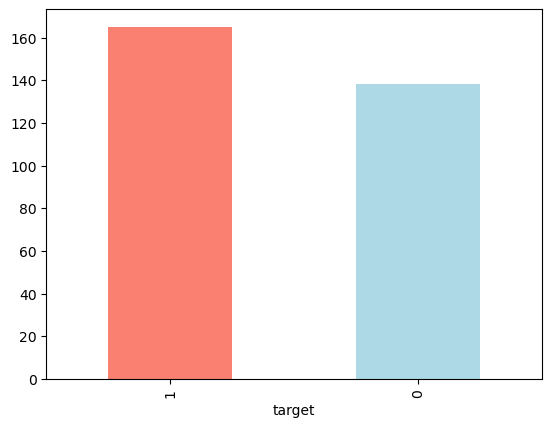

In [13]:
df["target"].value_counts().plot(kind="bar",color=["salmon","lightblue"])
# 1= Patient has heart disease   0= Patient dont have no heart disease

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [15]:
# Are there any missing values? 
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [16]:
df.describe ()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency according to Sex

In [17]:
df.sex.value_counts ()   # 1= Male   0= Female

sex
1    207
0     96
Name: count, dtype: int64

In [18]:
#Compare target column with sex column 
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


<Axes: xlabel='target'>

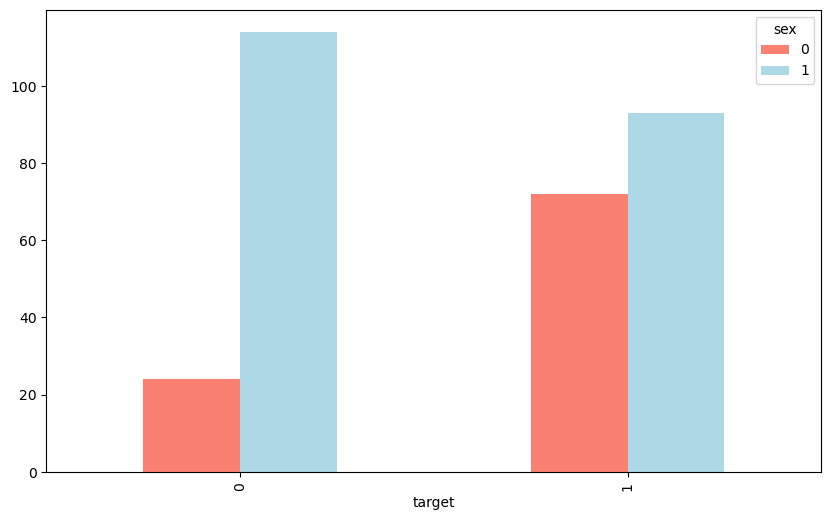

In [19]:
#Create a plot of crosstab 
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10,6),
                                    color=["Salmon", "Lightblue"])

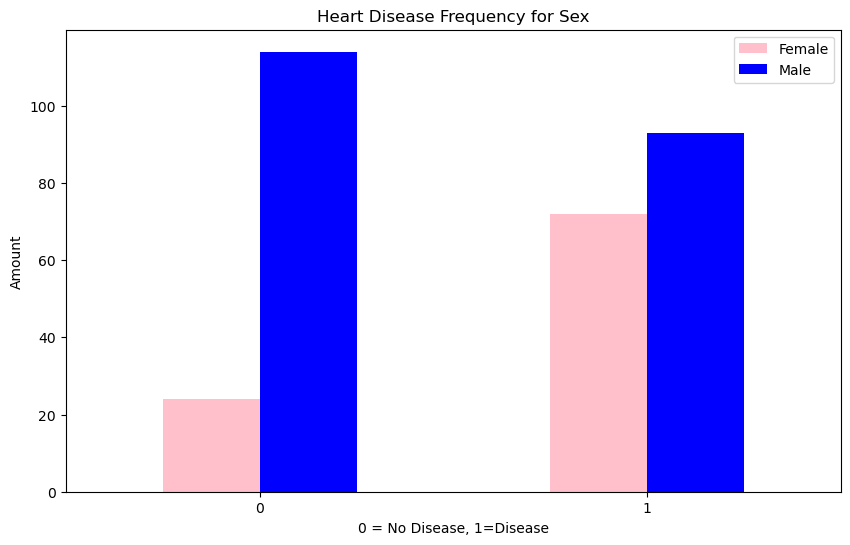

In [20]:
#Create a plot of Crosstab with more details
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10,6),
                                    color=["pink","blue"])

plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Disease, 1=Disease")
plt.ylabel("Amount")
plt.legend (["Female", "Male"]);
plt.xticks(rotation=0);

In [21]:
df.head ()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Age vs. Max Heart Rate for Heart Disease

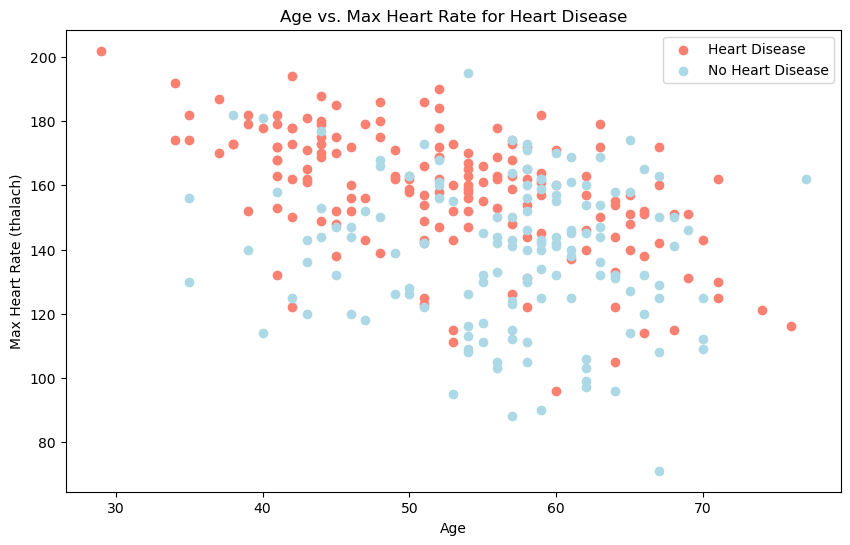

In [22]:
#Create a Scatter Plot 

# Create another figure
plt.figure(figsize=(10, 6))

# Scatter with positive examples
plt.scatter(
    df.age[df.target == 1],
    df.thalach[df.target == 1],
    c="salmon",
    label="Heart Disease"
)

# Scatter with negative examples
plt.scatter(
    df.age[df.target == 0],
    df.thalach[df.target == 0],
    c="lightblue",
    label="No Heart Disease"
)

plt.title("Age vs. Max Heart Rate for Heart Disease")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate (thalach)")
plt.legend()

plt.show()

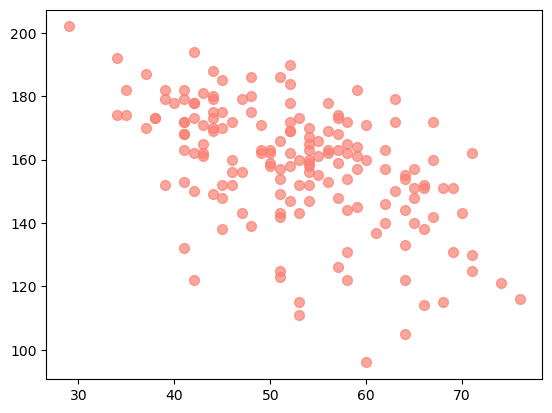

In [23]:
plt.scatter(
    df.age[df.target == 1],
    df.thalach[df.target == 1],
    c="salmon",
    alpha=0.7,
    s=50,
    label="Heart Disease"
)

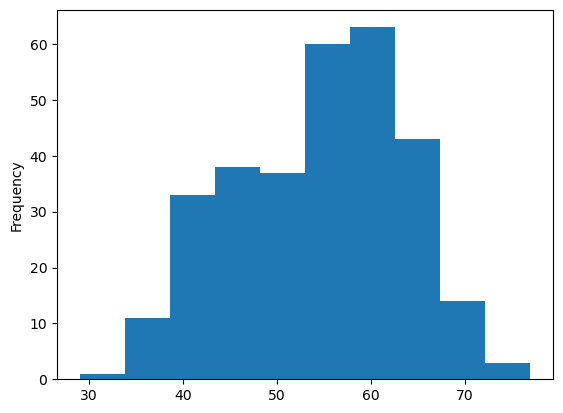

In [24]:
#Check the distribution of the age column with a histogram 
df.age.plot.hist();

# Heart Disease Frequency per Chest Pain Type 
3. cp - chest pain type
   0: Typical angina: Chest pain related decrease blood supply to heart
   1: Atypical angina: Chest pain not related to heart
   2: Non-anginal pain: typically esophageal spasms (Non heart related)
   3: Asymptomatic : Chest pain not showing signs of disease 

In [25]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


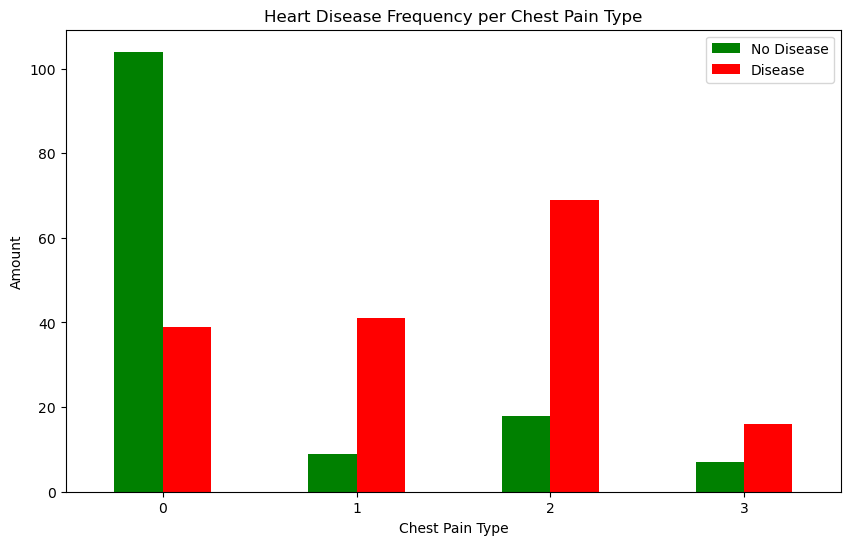

In [26]:
# Make the crosstab more visual 
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                   figsize=(10,6),
                                   color=["Green","Red"])
#Add some communication 
plt.title("Heart Disease Frequency per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease","Disease"])
plt.xticks(rotation=0);



In [27]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Finding Patterns

In [28]:
#Make a correlation matrix 
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


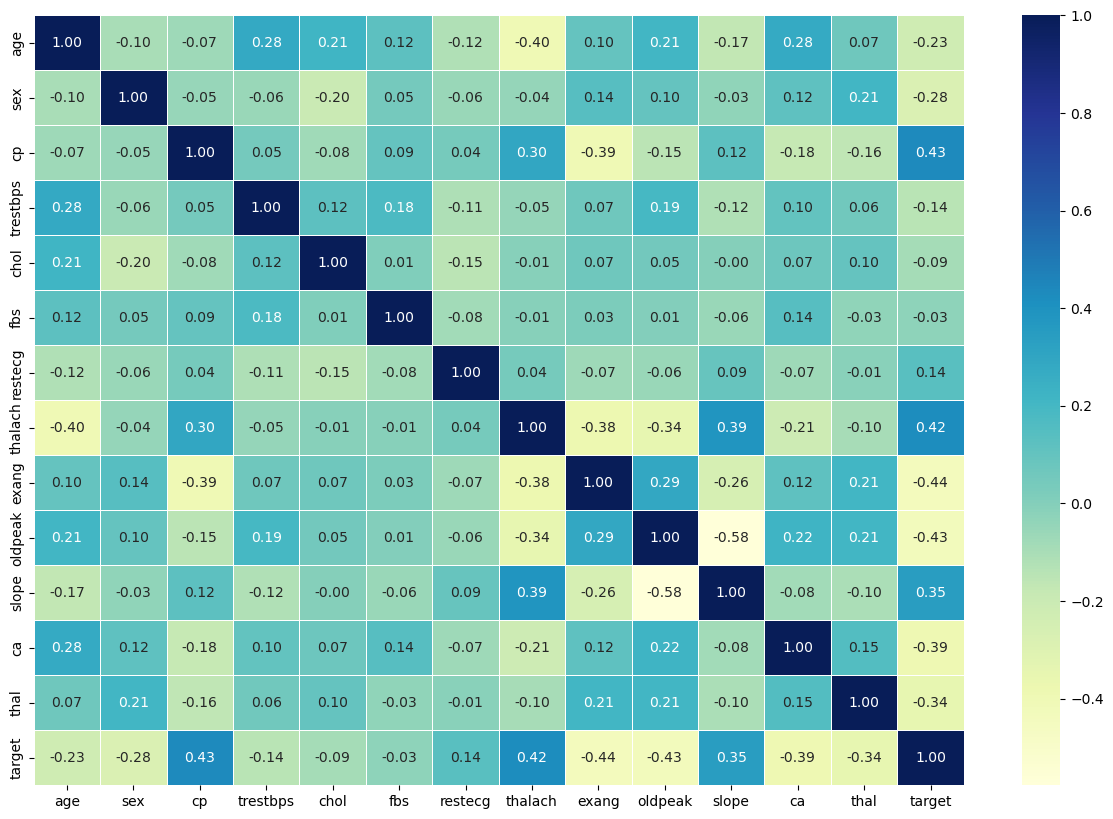

In [29]:
#let's make our correlation matrix a little prettier
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt=".2f",
                 cmap="YlGnBu");
        

# 5. Modelling 

In [30]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [31]:
#Split data into X and Y

X = df.drop("target", axis=1)

y= df["target"]

In [32]:
X # lets visualize X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [33]:
y # Lets visualize Y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [34]:
#Split data into train and test sets
np.random.seed(42)

#Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2)

In [35]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [36]:
y_train, len(y_train)

(132    1
 202    0
 196    0
 75     1
 176    0
       ..
 188    0
 71     1
 106    1
 270    0
 102    1
 Name: target, Length: 242, dtype: int64,
 242)

## Choosing the Right Model

Now we've got our data split into training and test set, it's time to build a machine learning model. 

We'll train it (find the patterns) on the training set. 

And we'll test it (use the patterns) on the test set.

We're going to try 3 different machine learning models: 
1. Logistic Regression
2. K-Nearest Neighbours Classifier
3. Random Forest Classifier 

In [37]:
# Put models in a dictionary
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

# Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    """

    # Set random seed
    np.random.seed(42)

    # Make a dictionary to keep model scores
    model_scores = {}

    # Loop through models
    for name, model in models.items():

        # Fit the model to the data
        model.fit(X_train, y_train)

        # Evaluate the model
        model_scores[name] = model.score(X_test, y_test)

    return model_scores

In [38]:
model_scores = fit_and_score(
    models=models,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

model_scores

C:\Users\amado\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

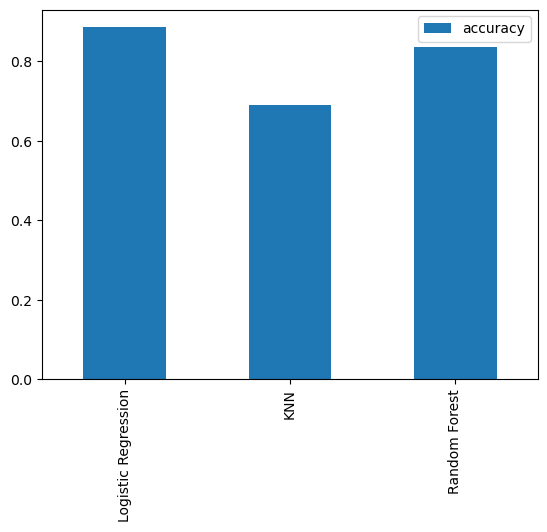

In [39]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar();

Now we've got baseline model... and we know a model's first predictions are not always what we should based our next step off. 
What should we do?

Let's look at the following: 
* Hyperparameter tuning
* Feature importance
* Confusion matrix
* Cross-validation
* Precision
* Recall
* F1 score
* Classification report
* ROC curve
* Area under the curve (AUC)

## Hyperparameter tuning

In [40]:
#Let's tune KNN

train_scores = []
test_scores = []

#Create a list of different values for n_neighbors 
neighbors = range(1,21)

#Setup KNN instance 
knn = KNeighborsClassifier()

#Loop through different n_neighbors 
for i in neighbors:
    knn.set_params(n_neighbors=i)

    # Fit the algorithm 
    knn.fit(X_train, y_train)

    # Update the training scores list
    train_scores.append(knn.score(X_train, y_train))

    # Update the test scores list
    test_scores.append(knn.score(X_test,y_test))


In [41]:
train_scores

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

In [42]:
test_scores

[0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6721311475409836,
 0.6885245901639344,
 0.7213114754098361,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.6557377049180327]

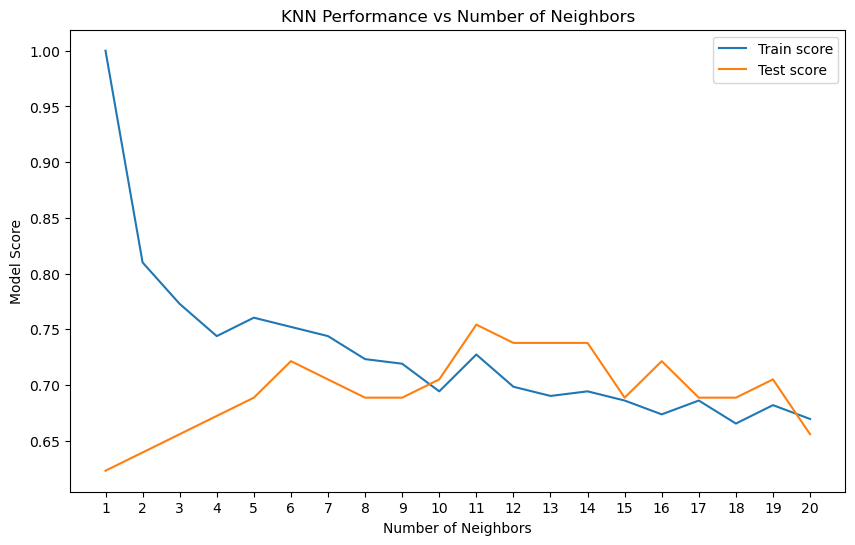

Maximum KNN score on the test data: 75.41%


In [43]:
plt.figure(figsize=(10,6))

plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")

plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of Neighbors")
plt.ylabel("Model Score")
plt.title("KNN Performance vs Number of Neighbors")
plt.legend()

plt.show()

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

## Hyperparameter tuning with RandomizedSearchCV
* LogisticRegression()
* RandomForestClassifier()
* ..... using RandomizedSearchCV

In [44]:
#Create a hyperparameter grid for LogisticRegression 
log_reg_grid = {"C": np.logspace (-4,4,20),
                "solver": ["liblinear"]}

In [45]:
np.logspace(-4,4,20)


array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04])

In [46]:

# Create a hyperparameter grid for RandomForestClassifier

rf_grid = {
    "n_estimators": np.arange(10, 1000, 50),
    "max_depth": [None, 3, 5, 10, 20, 30],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2)
}

rf_grid

{'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
        660, 710, 760, 810, 860, 910, 960]),
 'max_depth': [None, 3, 5, 10, 20, 30],
 'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
 'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])}

Now we've got hyperparameter grids setup for each of our models, let's tune them using RandomizedSearcgCV..

## Tuning Hyperparameter 2

In [58]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Tune Logistic Regression
np.random.seed(42)

# Setup random hyperparameter search
rs_log_reg = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=log_reg_grid,
    cv=5,
    n_iter=20,
    verbose=True,
    random_state=42
)

# Fit random hyperparameter search model
rs_log_reg.fit(X_train, y_train)

# Best parameters
print(rs_log_reg.best_params_)

# Best score
print(rs_log_reg.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}
0.8346088435374149


In [59]:

rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [60]:
#Find the best hyperparameters 
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [61]:
#Evaluate the randomized search RandomForestClassifier model
rs_log_reg.score(X_test, y_test)

0.8852459016393442

## Tuning Hyperparameter 3 

In [62]:
model_scores

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

# Evaluating our Model

## Evaluating our tuned machine leaning classifier, beyond accuracy 
* ROC curve and AUC score
* Confusion matrix
* classification
* Precision
* Recall
* F1-score
... and it would be great if cross-validation was used where possible.
  To make comparaisons and evaluate our trained model, first we need to make predictions. 

In [64]:
# Make predictions with tuned model
y_preds = rs_log_reg.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_preds))
print(classification_report(y_test, y_preds))
print(confusion_matrix(y_test, y_preds))

Accuracy: 0.8852459016393442
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61

[[25  4]
 [ 3 29]]


In [66]:
from sklearn.model_selection import GridSearchCV

gs_log_reg = GridSearchCV(
    LogisticRegression(),
    param_grid=log_reg_grid,
    cv=5
)

gs_log_reg.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


Accuracy: 0.8852459016393442
Precision: 0.8787878787878788
Recall: 0.90625
F1 Score: 0.8923076923076924

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61


Confusion Matrix:
[[25  4]
 [ 3 29]]


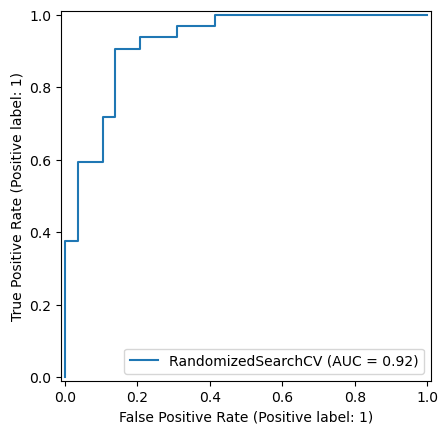

In [69]:
from sklearn.metrics import (
    RocCurveDisplay,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

# Make predictions
y_preds = rs_log_reg.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_preds))

# Precision
print("Precision:", precision_score(y_test, y_preds))

# Recall
print("Recall:", recall_score(y_test, y_preds))

# F1 Score
print("F1 Score:", f1_score(y_test, y_preds))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_preds))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_preds))

# ROC Curve + AUC
RocCurveDisplay.from_estimator(rs_log_reg, X_test, y_test)
plt.show()

<module 'matplotlib.pyplot' from 'C:\\Users\\amado\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

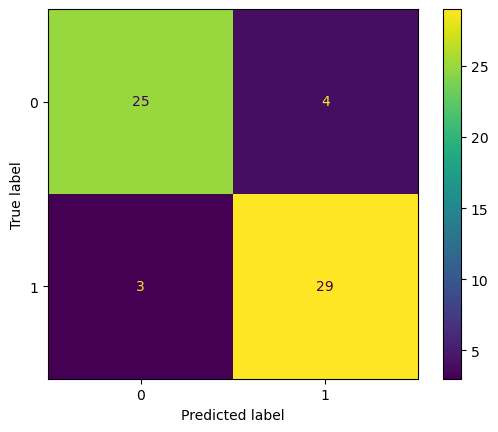

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_preds = rs_log_reg.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_preds)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt

## Evaluating our Model 2 
Now we've got a ROC curve, and AUC metric and a confusion matrix, let's get a classification report as well as cross-validated precision, recall and f1-score 

In [71]:
print (classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



## Evaluating our Model 3 
### Calculate evaluation metrics using cross-validation 
We're going to calculate accuracy, precision, recal and f1-score of our model using cross-validation and to do so we'll be using cross_val_score()

In [72]:
# Create Logistic Regression model with best parameters
clf = LogisticRegression(
    C=0.23357214690901212,  # Replace with your best C value
    solver="liblinear"
)

# Cross-validated accuracy
cv_acc = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

# Cross-validated precision
cv_precision = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring="precision"
)

# Cross-validated recall
cv_recall = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring="recall"
)

# Cross-validated F1
cv_f1 = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("CV Accuracy:", np.mean(cv_acc))
print("CV Precision:", np.mean(cv_precision))
print("CV Recall:", np.mean(cv_recall))
print("CV F1 Score:", np.mean(cv_f1))

CV Accuracy: 0.8479781420765027
CV Precision: 0.8215873015873015
CV Recall: 0.9272727272727274
CV F1 Score: 0.8705403543192143


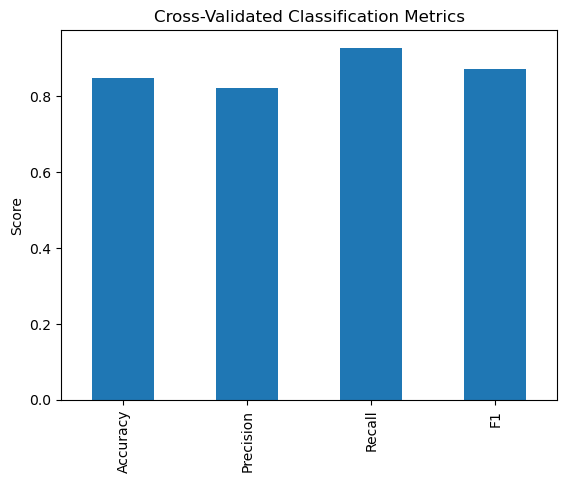

In [74]:


cv_metrics = pd.DataFrame({
    "Accuracy": np.mean(cv_acc),
    "Precision": np.mean(cv_precision),
    "Recall": np.mean(cv_recall),
    "F1": np.mean(cv_f1)
}, index=[0])

cv_metrics.T.plot.bar(
    title="Cross-Validated Classification Metrics",
    legend=False
)

plt.ylabel("Score")
plt.show()

## Finding the Most Important Features (Feature importance)
* Feature importance is another as asking , "Which features contributed most to the outcomes of the model and how did they contibute?"
* Finding feature importance is different for each machine learning model.



In [77]:
df.head ()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


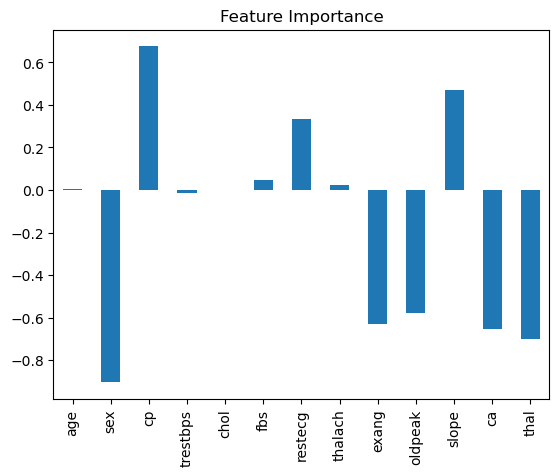

In [78]:
# Find most important features from Logistic Regression model

# Fit model with best hyperparameters
clf = LogisticRegression(
    C=0.23357214690901212,
    solver="liblinear"
)

clf.fit(X_train, y_train)

# Match coefficients to feature names
feature_dict = dict(zip(X.columns, list(clf.coef_[0])))

# Convert to DataFrame
feature_df = pd.DataFrame(
    feature_dict,
    index=[0]
)

feature_df.T.plot.bar(
    title="Feature Importance",
    legend=False
);

In [79]:
pd.crosstab(df["sex"], df["target"])

target,0,1
sex,,
0,24,72
1,114,93


slope-the slope of the peak exercise ST segment 
* 0: Upsloping: better heart rate with excercise (uncommon)
* 1: Flatsloping: minimal change (typical healthy heart)
* 2: Downslopins: signs of unhealthy heart 

# 6. Experimentation 
During experimentation, multiple machine learning models and hyperparameters were tested to improve prediction performance.

Models evaluated:
- Logistic Regression
- Random Forest Classifier

Techniques used:
- Train/Test Split
- RandomizedSearchCV
- Cross Validation
- Feature Importance Analysis

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Results:
- Logistic Regression achieved the best overall balance of performance and interpretability.
- Hyperparameter tuning improved model performance compared to the baseline model.
- Feature importance analysis identified the most influential predictors of heart disease.

Future Improvements:
- Test XGBoost and Gradient Boosting models.
- Perform feature engineering.
- Collect additional data.
- Deploy the model using Streamlit or Flask.

In [80]:
# Experiment 1 - Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Experiment 2 - Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Compare models
print("Logistic Regression Score:", log_reg.score(X_test, y_test))
print("Random Forest Score:", rf.score(X_test, y_test))

Logistic Regression Score: 0.8852459016393442
Random Forest Score: 0.8360655737704918


C:\Users\amado\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1. Run the Entire Notebook

In Jupyter Notebook:

Menu → Kernel → Restart & Run All

This will:

Clear memory
Run every cell from top to bottom
Confirm there are no hidden errors

If everything runs successfully, your project is working.

2. Verify Final Outputs

Make sure you can show:

    